# Positioning the IQM-Based Mixed-Effects Harmonisation Framework

In this course, we will demonstrate an IQM-based harmonisation workflow for removing batch effects from imaging-derived phenotypes (IDPs). 

The framework implements a relatively lightweight and interpretable harmonisation strategy within a linear mixed-effects modelling framework. Rather than modelling site effects directly at the level of the imaging-derived phenotypes (IDPs), the approach uses image quality metrics (IQMs) to identify latent nuisance structure associated with site variability. Additive (mean-shift) and multiplicative (variance scaling) correction is then applied selectively using mixed-effects models.

Conceptually, the framework can be viewed as a QC-informed harmonisation approach in which:

- scanner/site information is used to identify nuisance-related QC structure,
- biologically meaningful covariates are explicitly protected during QC selection,
- and correction is applied only when statistically justified.

Importantly, harmonisation is not imposed uniformly across all observations or phenotypes. Instead, the framework adaptively determines:

- which QC components are relevant for a given IDP,
- whether additive correction is appropriate,
- and whether multiplicative scaling sufficiently improves model fit to justify correction.

This differs from direct batch-normalisation approaches, such as ComBat harmonisation, where site correction is applied by explicitly specifying batch labels.

The framework is intentionally simple and transparent:

- modelling assumptions are linear,
- nuisance structure remains interpretable through QC variables,
- and harmonisation can be evaluated using standard mixed-effects diagnostics.

Such an approach may be particularly useful in:

- smaller datasets or setting with limited number of data points per site
- longitudinal studies,

More advanced approaches, such as [BARTharm](https://doi.org/10.1101/2025.06.04.657792), extend QC-informed harmonisation into substantially more flexible modelling frameworks. BARTharm uses Bayesian Additive Regression Trees (BART) to capture nonlinear relationships and higher-order interactions between image-quality structure, scanner effects, and biological variation. This approaches may provide a more robust representation of complex nuisance structure in large and heterogeneous datasets where scanner effects are unlikely to be adequately described by linear relationships alone.

Accordingly, the present workflow should be viewed as:

- a transparent and interpretable mixed-effects implementation,
- a useful pedagogical introduction to IQM-guided harmonisation,
- and a practical approach for smaller or clinically constrained datasets.

Together, these methods illustrate a broader shift away from direct batch-label correction toward harmonisation strategies that explicitly leverage image-quality information to characterise nuisance variation, thereby reducing technical variability without compromising biological variability or inducing overcorrection.

## Further reading
Comprehensive methodological documentation can be found at [this link](https://github.com/gvbhalerao591/Harmonisation-Paper/blob/main/manuscript_materials/AppendixA-IQM-informed_harmonisation.pdf).


In [ ]:
# install packages if required
%pip install numpy scipy pandas scikit-learn statsmodels matplotlib seaborn

## Inputs Required for the Code

The required files are stored in the `iqm_light_data` folder. This folder contains:

- **simulated_data.csv** — contains all IQMs and IDPs for each observation in the dataset. In this dataset we have one IDP to be harmonised and several QC metrics.

- **idp_list.csv** — contains the list of IDPs to be harmonised. These must match the corresponding column names in *simulated_data.csv*.

- **iqm_list.csv** — contains the list of IQMs to be used in the harmonisation workflow. These must match the corresponding column names in *simulated_data.csv*.

## Arguments to the Harmonisation Function

We will use the `iqm_harmonise` function from `iqm_harmonisation_light.py`. We recommend reviewing both the implementation and the inline documentation describing the function arguments before applying the workflow to your own datasets.

## Harmonisation Parameters

In this example, we specify the following arguments:

* **`preserve_covars`**
  Covariates representing biological sources of variability that should be preserved during harmonisation (e.g., `age`).

* **`adjust_covars`**
  Additional covariates to be included in the harmonisation model as adjustment terms (e.g., `timepoint`).

* **`reverse_guard_covars`**
  Covariates included in the reverse-guard model (e.g., `age`) to explicitly safeguard biologically meaningful variation and minimise the risk of overcorrection.

* **`categorical_covars`**
  A list of covariates to be treated as categorical factors within the model.

* **`p_thr`**
  Statistical significance threshold used during QC-feature selection. Any image-quality metric (IQM/QC feature) significantly associated with IDPs or protected covariates will be excluded from the correction model to avoid removal of biologically relevant signal.

* **`apply_pca`**
  Enables principal component analysis (PCA) on QC features prior to harmonisation.

* **`iqm_variance`**
  Proportion of variance in QC features to retain when deriving PCA components.

* **`enable_multiplicative`**
  Enables multiplicative harmonisation effects in addition to additive correction. As this substantially increases computational cost, it is disabled in the present example.


## Outputs

After running the IQM-based harmonisation workflow, several output files will be generated:

- *iqm_harmonised.csv*: contains the original and harmonised IDPs (`harmonised_<idp_name>`).
- *qc_selection_<additive/multiplicative>_details.csv*: contains statistical significance measures and summary information for QC selection.
- *selected_<additive/multiplicative>_by_volume.csv*: contains the QC variables selected for each IDP.

## Visualisation

Next, we will visualise the distribution of IDPs across batches using the outputs from *iqm_harmonised.csv*. 

*Can you see which QC features were selected for correction with the IDPs, and how do the IDP distributions appear across sites/batches before and after harmonisation?*

=== IQM Harmonization (Flexible Version) ===
P-value threshold: 0.0500
Max QCs per volume: inf
PCA variance threshold: 95.0%
Apply PCA: True
Preserve covars: ['Age']
Adjust covars: ['Timepoint']
Categorical covars: ['Timepoint', 'Batch']
Reverse-guard covars: ['Age']

Step 1: Preparing QC metrics...
  PCA input shape: (48, 6)
  Retaining PCs: 1 (99.94%)

Step 1b: Caching biology-only fits for multiplicative stage...
  Biology-only cache built.

Step 2: Selecting QCs for ADDITIVE correction...
  Criteria: batch-driven, not preserve-covariate-driven

=== Additive selection: IDP1 ===

=== Additive selection: IDP2 ===

=== Additive selection: IDP3 ===

=== Additive selection: IDP4 ===
  QCs selected: min=0, max=1, mean=0.8

Step 3: MULTIPLICATIVE correction disabled.

Step 4: Applying corrections...

=== Volume: IDP1 ===
  Additive correction: applying 1 QC(s) -> ['QC1']
  Multiplicative correction skipped.

=== Volume: IDP2 ===
  Additive correction: skipped (no QCs passed)
  Multiplicati

/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1564: RuntimeWarning: divide by zero encountered in log
  likeval -= self.n_totobs * np.log(qf) / 2.


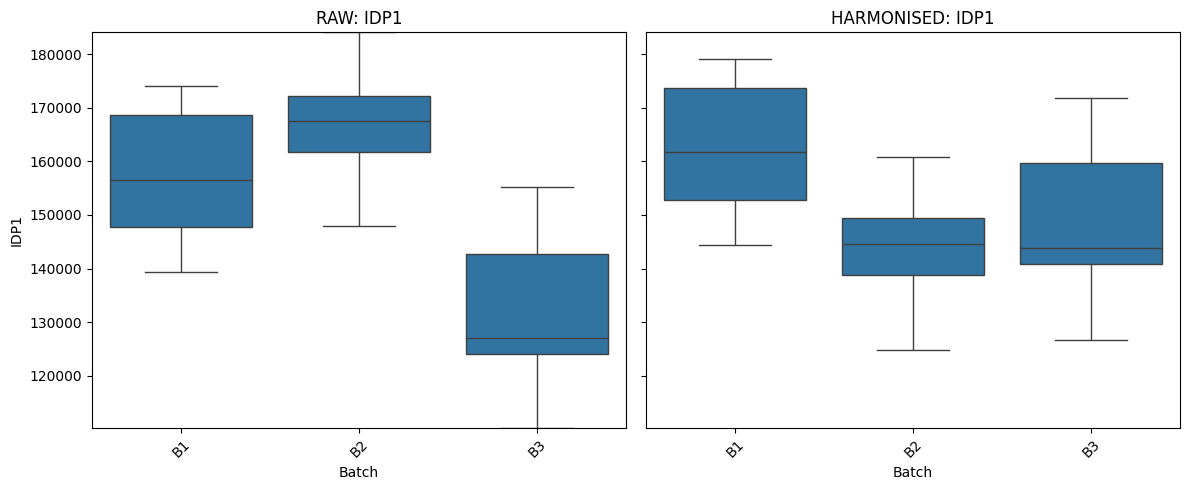

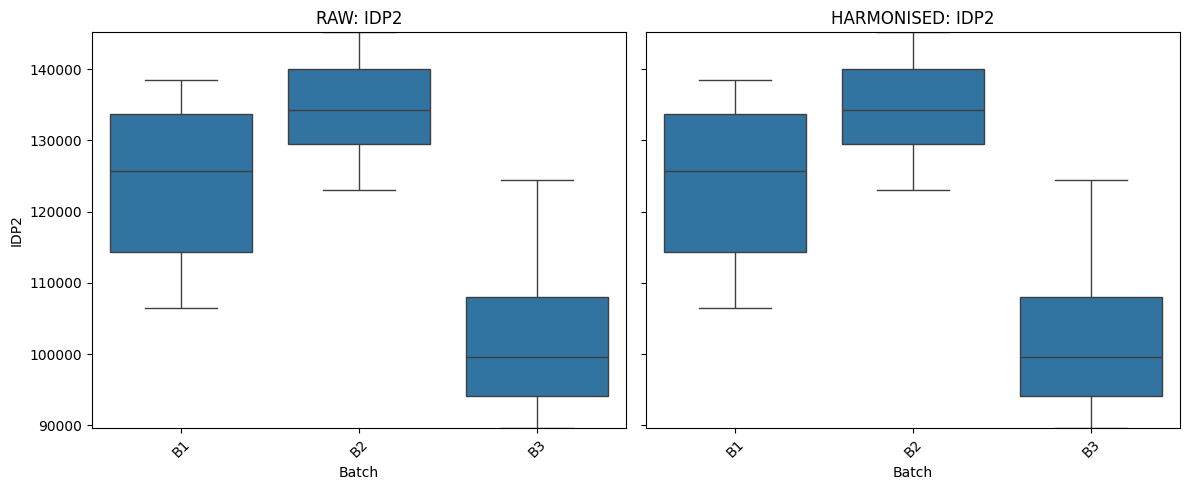

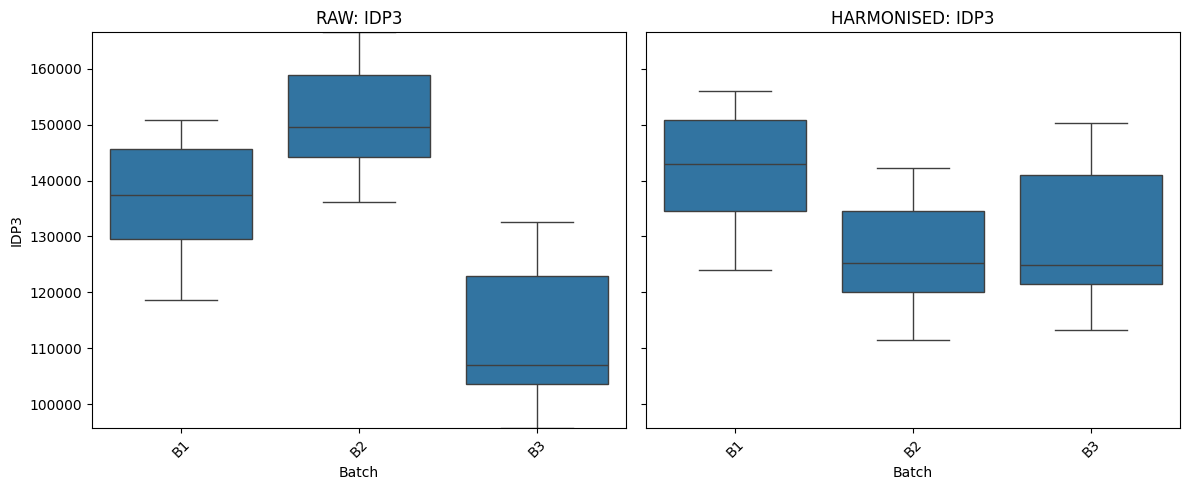

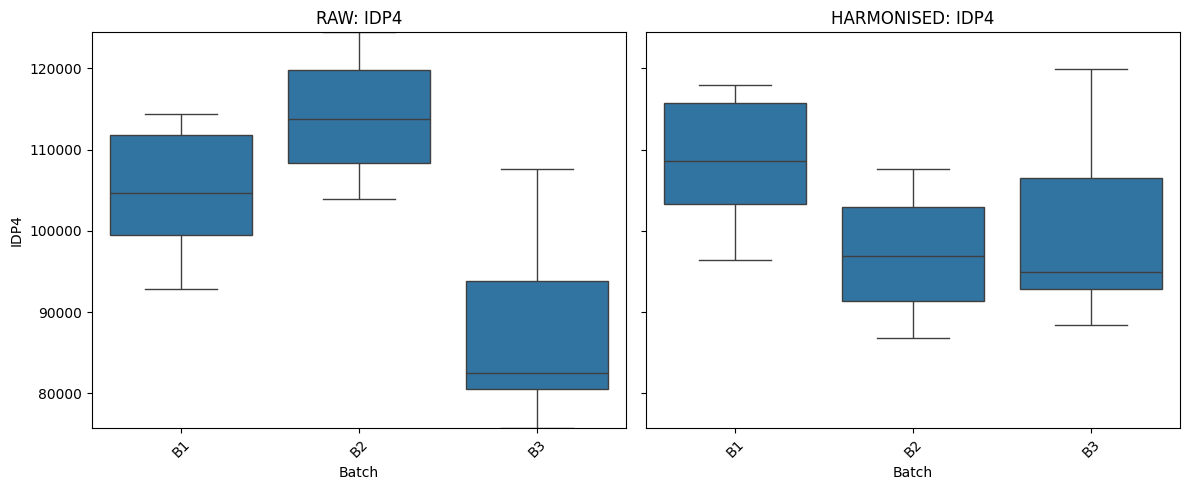

In [14]:
# Import packages and load data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
repo_root = Path.cwd().parent.parent
data_file     = repo_root / "data" / "data_block4" / "iqm_light_data" / "Simulated_data" / "simulated_data.csv"
iqm_list_file = repo_root / "data" / "data_block4" / "iqm_light_data" / "Simulated_data" / "iqm_list.csv"
idp_list_file = repo_root / "data" / "data_block4" / "iqm_light_data" / "Simulated_data" / "idp_list.csv"

from block4_utils.iqm_harmonisation_light import iqm_harmonise

df = pd.read_csv(data_file)
idp_list = pd.read_csv(idp_list_file, header=None).iloc[:, 0].dropna().astype(str).str.strip().tolist()
iqm_list = pd.read_csv(iqm_list_file, header=None).iloc[:, 0].dropna().astype(str).str.strip().tolist()

# Apply harmonisation
data_out, qc_selection, add_detail_df, mult_detail_df, summary_df = iqm_harmonise(
    data=df,
    idp_list=idp_list,
    qc_list=iqm_list,
    preserve_covars=("Age",),
    adjust_covars=("Timepoint",),
    reverse_guard_covars=("Age",),
    categorical_covars=("Timepoint", "Batch"),
    batch_col="Batch",
    subject_col="Subject",
    age_source_col="Age",
    batch_source_col="Batch",
    age_col="Age",
    p_thr=0.05,
    apply_pca=True,
    iqm_variance=95,
    verbose_model_fits=False,
    enable_multiplicative=False
)

# Visualise
for idp in idp_list:
    raw_col = idp
    harm_col = f"harmonised_{idp}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    ymin = min(data_out[raw_col].min(), data_out[harm_col].min())
    ymax = max(data_out[raw_col].max(), data_out[harm_col].max())

    sns.boxplot(data=data_out, x="Batch", y=raw_col, ax=axes[0])
    axes[0].set_title(f"RAW: {idp}")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_ylim(ymin, ymax)

    sns.boxplot(data=data_out, x="Batch", y=harm_col, ax=axes[1])
    axes[1].set_title(f"HARMONISED: {idp}")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

## Real data examples: 

### DPUK PET-MR dataset

We have applied this method on the T1w IDPs from Dementias Platform UK PET-MR dataset. More details are in this [preprint](https://doi.org/10.64898/2026.04.21.26351106). 

### ON-Harmony Dataset

Below is example code demonstrating how the IQM-based harmonisation workflow can be applied to a test-retest dataset such as [ON-Harmony](https://openneuro.org/datasets/ds004712/versions/2.0.1). See the data and prebaked results in folder `<repo_dir>/data/data_block4/iqm_light_data/Real_data/prebaked`.

For the purposes of this workshop, attendees can skip the execution and directly inspect the provided `.csv` and `.png` visualisations.

The provided figures show side-by-side boxplots of raw and harmonised IDPs across different batches/scanners and are intended to illustrate the qualitative effects of harmonisation.

Please note that the On-Harmony dataset is based on a test–retest acquisition design and is therefore already relatively well harmonised. Consequently, visual differences between raw and harmonised distributions may appear modest, particularly in univariate summaries.

=== IQM Harmonization (Flexible Version) ===
P-value threshold: 0.0500
Max QCs per volume: inf
PCA variance threshold: 95.0%
Apply PCA: True
Preserve covars: ['age']
Adjust covars: []
Categorical covars: ['scan_session']
Reverse-guard covars: ['age']

Step 1: Preparing QC metrics...
  Removing 3 zero-variance QCs
  ['T1w_spacing_x', 'T1w_spacing_y', 'T1w_spacing_z']
  PCA input shape: (120, 16)
  Retaining PCs: 5 (95.96%)

Step 1b: Caching biology-only fits for multiplicative stage...
  Biology-only cache built.

Step 2: Selecting QCs for ADDITIVE correction...
  Criteria: batch-driven, not preserve-covariate-driven

=== Additive selection: T1_SIENAX_WM_norm_vol ===
  QCs selected: min=4, max=4, mean=4.0

Step 3: Selecting QCs for MULTIPLICATIVE correction...
  NOTE: Multiplicative correction is computationally more intensive in the current Python implementation because it relies on repeated mixed-effects model fitting.

Step 3: Selecting QCs for MULTIPLICATIVE correction...
  KEY: Usi

/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1564: RuntimeWarning: divide by zero encountered in log
  likeval -= self.n_totobs * np.log(qf) / 2.
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block04/block4_utils/iqm_harmonisation_light.py:365: RuntimeWarning: invalid value encountered in scalar subtract
  lr_stat = 2.0 * (full_fit.llf - reduced_fit.llf)
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/.venv/lib/python3.12/site-packages/statsmodels/regression/mixed_linear_model.py:1564: RuntimeWarning: divide by zero encountered in log
  likeval -= self.n_totobs * np.log(qf) / 2.
/Users/psyc1586_admin/OHBM2026_educational_harmonisation/latest/OHBM2026_Educational_course_harmonization/notebooks/block04/block4_utils/iqm_harm

  QCs selected: min=0, max=0, mean=0.0

Step 4: Applying corrections...

=== Volume: T1_SIENAX_WM_norm_vol ===
  Additive correction: applying 4 QC(s) -> ['QC1', 'QC2', 'QC4', 'QC5']
  Multiplicative selection: using cached biology-only proxy
  Multiplicative correction: skipped (no QCs passed)

Step 5: Saving results...
  Data saved: iqm_harmonised.csv
  Summary saved: qc_selection_summary.csv
  Additive details saved: qc_selection_additive_details.csv
  Multiplicative details saved: qc_selection_multiplicative_details.csv
  Selected QC lists saved.

=== SUMMARY ===
T1_SIENAX_WM_norm_vol: additive=4 QC(s), multiplicative=0 QC(s), multiplicative_applied=False

Done!


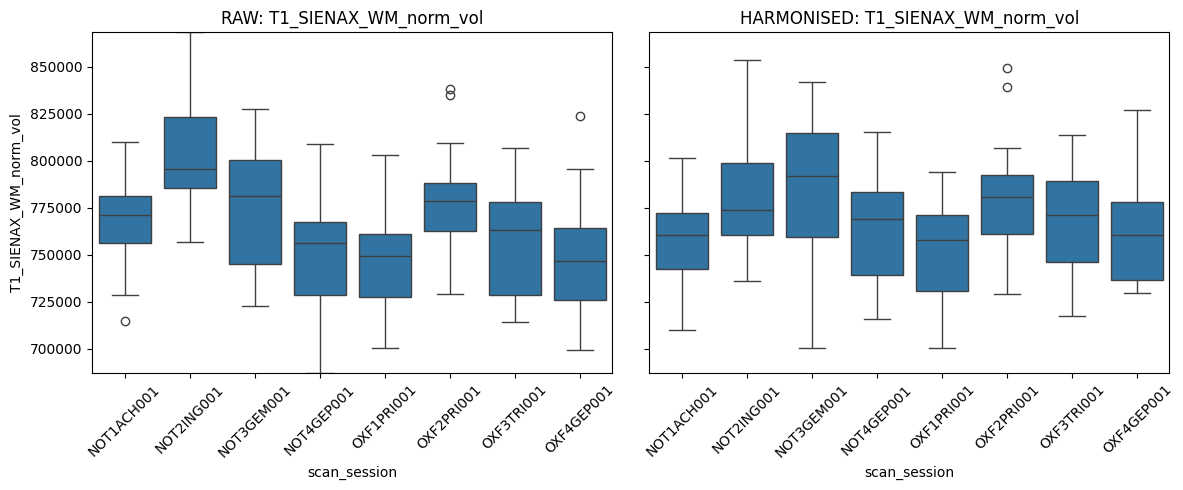

In [22]:
# IMPORTNAT: Running this code might take time so you can skip this and directly see the files and plots already generated 
# See <repo_dir>/data/data_block4/iqm_light_data/Real_data/prebaked

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
repo_root = Path.cwd().parent.parent
data_file     = repo_root / "data" / "data_block4" / "iqm_light_data" / "Real_data" / "onharmony.csv"
iqm_list_file = repo_root / "data" / "data_block4" / "iqm_light_data" / "Real_data" / "iqm_list.csv"
idp_list_file = repo_root / "data" / "data_block4" / "iqm_light_data" / "Real_data" / "idp_list.csv"

from block4_utils.iqm_harmonisation_light import iqm_harmonise

df = pd.read_csv(data_file)
idp_list = pd.read_csv(idp_list_file, header=None).iloc[:, 0].dropna().astype(str).str.strip().tolist()
iqm_list = pd.read_csv(iqm_list_file, header=None).iloc[:, 0].dropna().astype(str).str.strip().tolist()


data_out, qc_selection, add_detail_df, mult_detail_df, summary_df = iqm_harmonise(
    data=df,
    idp_list=idp_list,
    qc_list=iqm_list,
    preserve_covars=("age",),
    adjust_covars=(),
    reverse_guard_covars=("age",),
    categorical_covars=("scan_session",),
    batch_col="scan_session",
    subject_col="subject",
    age_source_col="age",
    batch_source_col="scan_session",
    age_col="age",
    iqm_variance=95,
    p_thr=0.05,
    apply_pca=True,
    verbose_model_fits=False,
    maxiter=500,
    enable_multiplicative=True
)
# Visualise
for idp in idp_list:
    raw_col = idp
    harm_col = f"harmonised_{idp}"

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

    ymin = min(data_out[raw_col].min(), data_out[harm_col].min())
    ymax = max(data_out[raw_col].max(), data_out[harm_col].max())

    sns.boxplot(data=data_out, x="scan_session", y=raw_col, ax=axes[0])
    axes[0].set_title(f"RAW: {idp}")
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_ylim(ymin, ymax)

    sns.boxplot(data=data_out, x="scan_session", y=harm_col, ax=axes[1])
    axes[1].set_title(f"HARMONISED: {idp}")
    axes[1].tick_params(axis="x", rotation=45)
    axes[1].set_ylim(ymin, ymax)

    plt.tight_layout()
    plt.show()

## Conceptual Notes and Limitations

The current implementation still makes use of an explicit batch/scanner variable during the IQM selection stage. In this sense, the workflow remains partially batch-guided, similar to methods such as ComBat, which also rely on known batch labels during harmonisation.

However, unlike direct batch-correction methods, the site/scanner/batch labels are not used directly to correct the imaging-derived phenotypes (IDPs). Instead, the framework first identifies image quality metrics (IQMs) that appear to capture scanner- or acquisition-related nuisance variation while avoiding IQMs that strongly encode biological or protected covariates. The selected IQMs are then used to guide harmonisation of the IDPs.

Conceptually, this makes the approach more indirect and relatively conservative compared with methods that directly regress out batch effects from all features. Correction is only driven by QC variables that satisfy the predefined statistical selection criteria, rather than by the site/scanner/batch labels themselves.

One motivation for this strategy is that direct batch-correction approaches can sometimes increase the risk of over-correction, particularly in smaller or heterogeneous datasets where scanner effects may be partially entangled with genuine biological variation. By constraining harmonisation through selected IQMs, the framework attempts to reduce removal of biologically meaningful signal while still mitigating nuisance variation.

More advanced IQM-driven approaches, such as BARTharm, move further away from explicit batch-guided correction by learning nuisance structure directly from image-quality patterns using more flexible nonlinear modelling strategies.

**Regardless of the harmonisation method used, harmonised outputs should always be evaluated carefully using multiple complementary metrics to assess both nuisance removal and preservation of biological signal.**

### Note on Reproducibility Across Implementations

For the real-data example, visualisations and outputs are generated from a separate [MATLAB implementation](https://github.com/gvbhalerao591/Harmonisation-Paper/tree/main/harmonisation_methods/IQM_approach/flexible_implementation_matlab) of the pipeline. The MATLAB implementation currently provides more stable and empirically robust harmonisation behaviour in this dataset, including more consistent QC selection and clearer post-harmonisation distributions. 

As a result, attendees should not expect the Python outputs to exactly reproduce the provided reference figures or selected QC variables.

Differences may arise from several factors, including:

- implementation differences between MATLAB and Python statistical libraries,
- optimisation procedures used in mixed-effects modelling,
- numerical estimation tolerances,
- and handling of variance components or convergence criteria.

For example, MATLAB's `fitlme` and Python's `statsmodels` mixed-effects implementations are not mathematically identical and may produce slightly different parameter estimates, significance values, or QC selection behaviour.

The Python implementation is therefore intended primarily as an educational and transparent demonstration of the workflow, while the provided reference outputs illustrate behaviour from the more extensively validated implementation.